# 定义state/node/graph

In [29]:
from pydantic import BaseModel,Field
from langgraph.graph import StateGraph,START,END
from typing import Annotated,Literal
import operator

class State(BaseModel):
    aggregate:Annotated[list,operator.add] = Field(default_factory=list)
    aggregate_len:int = Field(default=0)

def node1(state:State) ->dict:
    new_items = ["1"]
    return {
        "aggregate": new_items,
        "aggregate_len": len(state.aggregate) + 1
    }
def node2(state:State) -> dict:
   new_items = ["2"]
   return {
        "aggregate": new_items,
        "aggregate_len": len(state.aggregate) + 1
    }

graph_builder = StateGraph(State)

graph_builder.add_node("node1",node1)
graph_builder.add_node("node2",node2)


def route(state:State)->Literal["node2",END]:
    if state.aggregate_len < 5:
        return "node2"
    else:
        return END

graph_builder.add_edge(START,"node1")

graph_builder.add_conditional_edges(
    "node1",
    route,
     {
        "node2": "node2",
        END: END
    }
)
graph_builder.add_edge("node2","node1")

graph = graph_builder.compile()


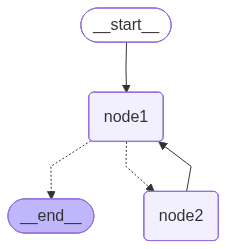

In [30]:
from IPython.display import Image,display

display(Image(graph.get_graph().draw_mermaid_png()))

In [31]:
graph.invoke({
    "aggregate":[],
    "aggregate_len":0
})

{'aggregate': ['1', '2', '1', '2', '1'], 'aggregate_len': 5}

# 递归限制

In [37]:
from langgraph.errors import GraphRecursionError

try:
    graph.invoke({
        "aggregate":[],
        "aggregate_len":0
    },{"recursion_limit":2})
except GraphRecursionError as e:
    print("Recursion error")

Recursion error
